In [1]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_customer_analysis_v2.csv to online_retail_customer_analysis_v2.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

sales = pd.read_csv(
    "online_retail_customer_analysis_v2.csv",
    parse_dates=["InvoiceDate"],
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string"
    },
    low_memory=False
)

sales["CustomerID"] = sales["CustomerID"].astype(int)

print("Shape:", sales.shape)
print("Customers:", sales["CustomerID"].nunique())
print("Date range:")
print(sales["InvoiceDate"].min(), sales["InvoiceDate"].max())

sales.head()

Shape: (392692, 12)
Customers: 4338
Date range:
2010-12-01 08:26:00 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth,DayName,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday,8


5.2 What is RFM?

| Measure   | Meaning                                   | Preferred result |
| --------- | ----------------------------------------- | ---------------- |
| Recency   | Days since the customer’s latest purchase | Lower            |
| Frequency | Number of unique orders                   | Higher           |
| Monetary  | Total customer spending                   | Higher           |


5.3 Calculate RFM values

Use one day after the latest transaction as the reference date:

In [3]:
reference_date = sales["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    sales.groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm = rfm[
    (rfm["Recency"] >= 0) &
    (rfm["Frequency"] > 0) &
    (rfm["Monetary"] > 0)
].copy()

print("RFM shape:", rfm.shape)
rfm.head()

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


View the distributions:

In [4]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.00000
mean,92.536422,4.272015,2048.68808
std,100.014169,7.697998,8985.23022
min,1.000000,1.000000,3.75000
25%,18.000000,1.000000,306.48250
50%,51.000000,2.000000,668.57000
75%,142.000000,5.000000,1660.59750
max,374.000000,209.000000,280206.02000


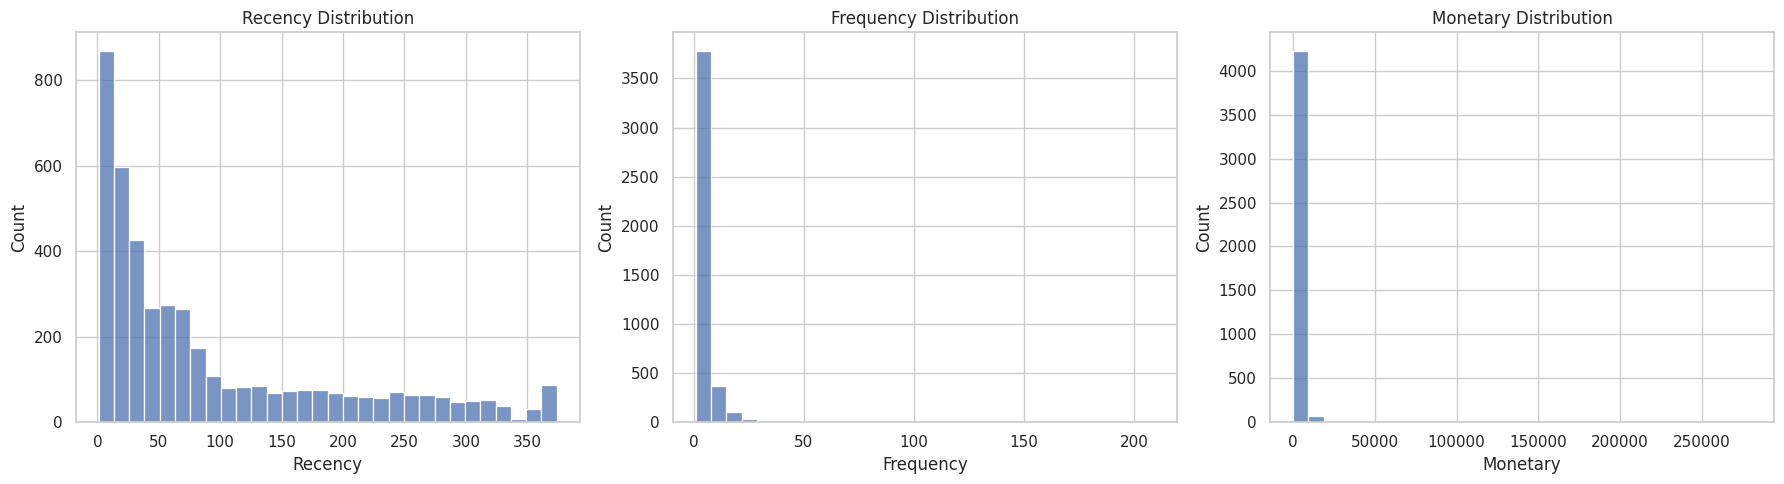

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

5.4 Create RFM scores

Scores range from 1 to 4. A score of 4 represents the most valuable behaviour.

In [6]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Total"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm["RFM_Code"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,RFM_Code
0,12346,326,1,77183.60,1,1,4,6,114
1,12347,2,7,4310.00,4,4,4,12,444
2,12348,75,4,1797.24,2,3,4,9,234
3,12349,19,1,1757.55,3,1,4,8,314
4,12350,310,1,334.40,1,1,2,4,112


5.5 Assign understandable customer segments

In [7]:
def assign_rfm_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r == 4 and f == 4 and m == 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r == 4 and f == 1:
        return "New Customers"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r == 1 and f <= 2:
        return "Lost Customers"

    elif r >= 3 and f >= 2:
        return "Potential Loyalists"

    else:
        return "Needs Attention"


rfm["RFM_Segment"] = rfm.apply(
    assign_rfm_segment,
    axis=1
)

segment_summary = (
    rfm.groupby("RFM_Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageSpending=("Monetary", "mean"),
        SegmentRevenue=("Monetary", "sum")
    )
    .sort_values("SegmentRevenue", ascending=False)
)

segment_summary[
    [
        "AverageRecency",
        "AverageFrequency",
        "AverageSpending",
        "SegmentRevenue"
    ]
] = segment_summary[
    [
        "AverageRecency",
        "AverageFrequency",
        "AverageSpending",
        "SegmentRevenue"
    ]
].round(2)

segment_summary

,RFM_Segment,Customers,AverageRecency,AverageFrequency,AverageSpending,SegmentRevenue
1,Champions,477,7.15,15.73,9188.47,4382901.95
3,Loyal Customers,1037,22.33,5.25,2109.01,2187038.86
0,At Risk,655,118.26,4.18,1606.72,1052403.65
2,Lost Customers,904,254.75,1.21,481.14,434949.54
6,Potential Loyalists,402,23.81,1.74,1008.81,405540.13
4,Needs Attention,791,71.88,1.24,506.26,400451.38
5,New Customers,72,9.40,1.00,332.27,23923.38


Plot the segments:

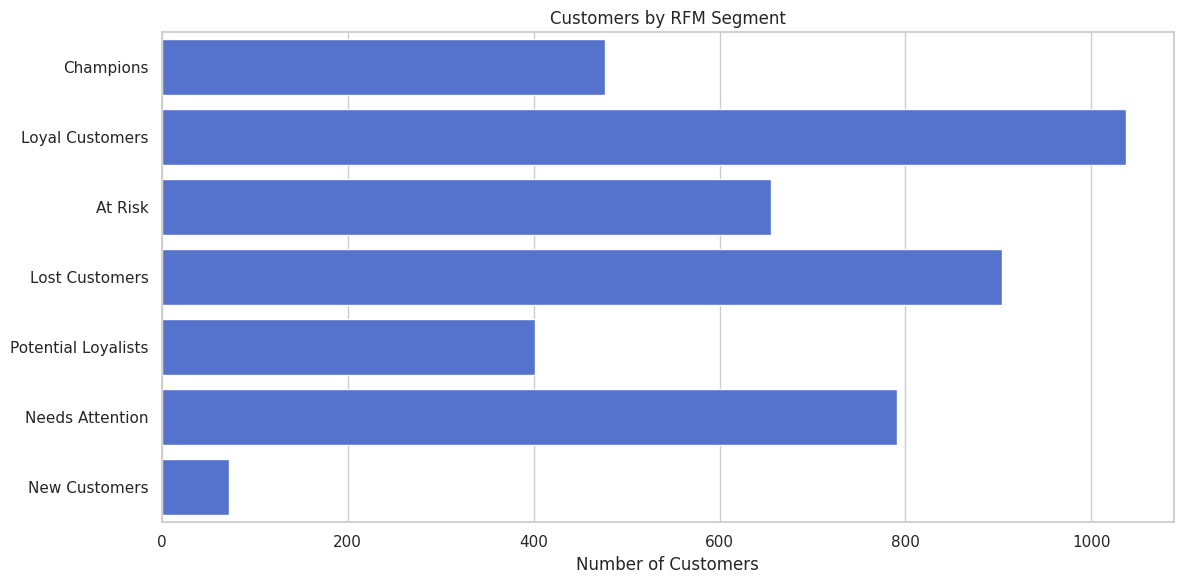

In [8]:
sns.barplot(
    data=segment_summary,
    y="RFM_Segment",
    x="Customers",
    color="royalblue"
)

plt.title("Customers by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("")
plt.tight_layout()
plt.show()

5.6 Prepare the data for K-Means

RFM values are highly skewed, so apply a logarithmic transformation before scaling.

In [9]:
clustering_features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

log_features = np.log1p(clustering_features)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(log_features)

scaled_features[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

5.7 Find the best number of clusters

Test between 2 and 8 clusters:

In [10]:
cluster_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(scaled_features)

    cluster_results.append({
        "Clusters": k,
        "Inertia": model.inertia_,
        "SilhouetteScore": silhouette_score(
            scaled_features,
            labels
        )
    })

cluster_results = pd.DataFrame(cluster_results)
cluster_results

,Clusters,Inertia,SilhouetteScore
0,2,6483.589424,0.432827
1,3,4869.488628,0.336517
2,4,3938.603205,0.337335
3,5,3296.708707,0.316200
4,6,2855.525595,0.312802
5,7,2548.820243,0.309186
6,8,2336.341052,0.303275


Plot the elbow and silhouette results:

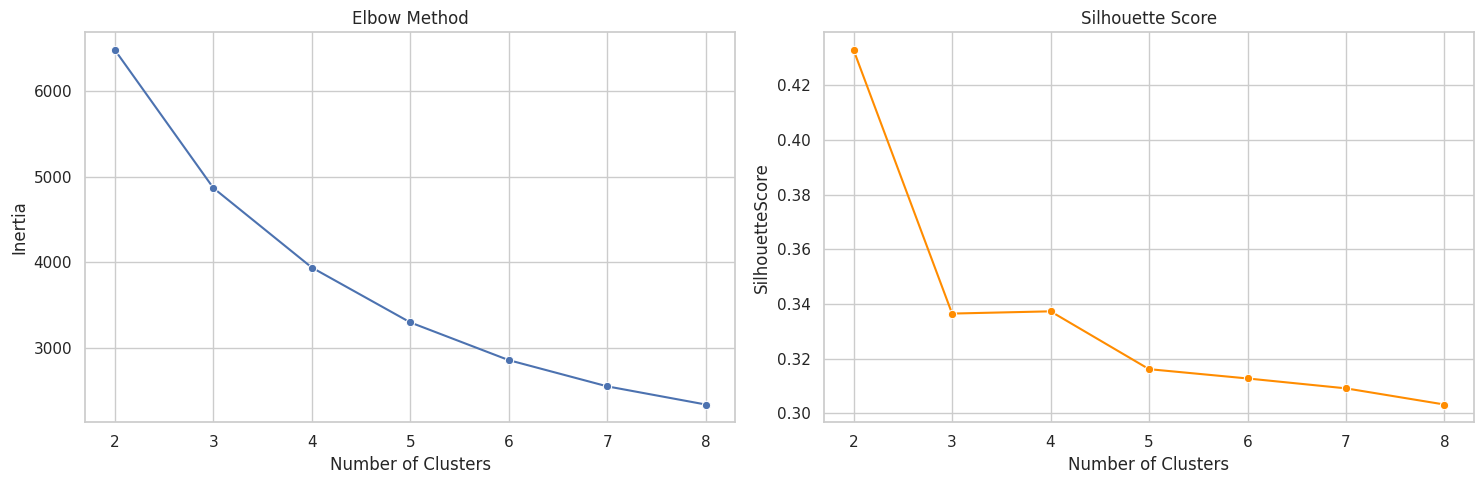

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=cluster_results,
    x="Clusters",
    y="Inertia",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")

sns.lineplot(
    data=cluster_results,
    x="Clusters",
    y="SilhouetteScore",
    marker="o",
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters")

plt.tight_layout()
plt.show()

5.8 Train the final K-Means model

Automatically select the cluster count with the highest silhouette score:

In [12]:
best_k = int(
    cluster_results.loc[
        cluster_results["SilhouetteScore"].idxmax(),
        "Clusters"
    ]
)

print("Selected clusters:", best_k)

final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

rfm["Cluster"] = final_model.fit_predict(scaled_features)

Selected clusters: 2


Evaluate the model:

In [13]:
silhouette = silhouette_score(
    scaled_features,
    rfm["Cluster"]
)

davies_bouldin = davies_bouldin_score(
    scaled_features,
    rfm["Cluster"]
)

print("Silhouette score:", round(silhouette, 3))
print("Davies-Bouldin score:", round(davies_bouldin, 3))

Silhouette score: 0.433
Davies-Bouldin score: 0.892


5.9 Examine the cluster profiles

In [14]:
cluster_profile = (
    rfm.groupby("Cluster", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageSpending=("Monetary", "mean"),
        TotalRevenue=("Monetary", "sum")
    )
)

numeric_columns = [
    "AverageRecency",
    "AverageFrequency",
    "AverageSpending",
    "TotalRevenue"
]

cluster_profile[numeric_columns] = (
    cluster_profile[numeric_columns].round(2)
)

cluster_profile

,Cluster,Customers,AverageRecency,AverageFrequency,AverageSpending,TotalRevenue
0,0,2672,134.09,1.67,495.59,1324229.69
1,1,1666,25.89,8.44,4539.60,7562979.20


Visualise the clusters:

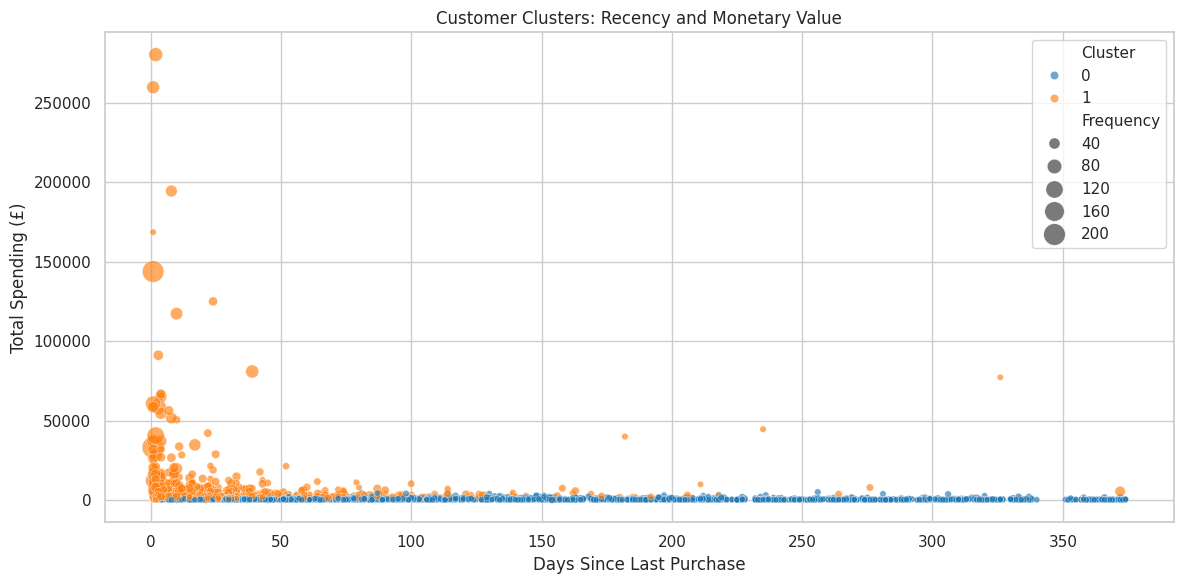

In [15]:
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    size="Frequency",
    sizes=(20, 250),
    alpha=0.65,
    palette="tab10"
)

plt.title("Customer Clusters: Recency and Monetary Value")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending (£)")
plt.tight_layout()
plt.show()

Use a logarithmic scale if a few customers compress the chart:

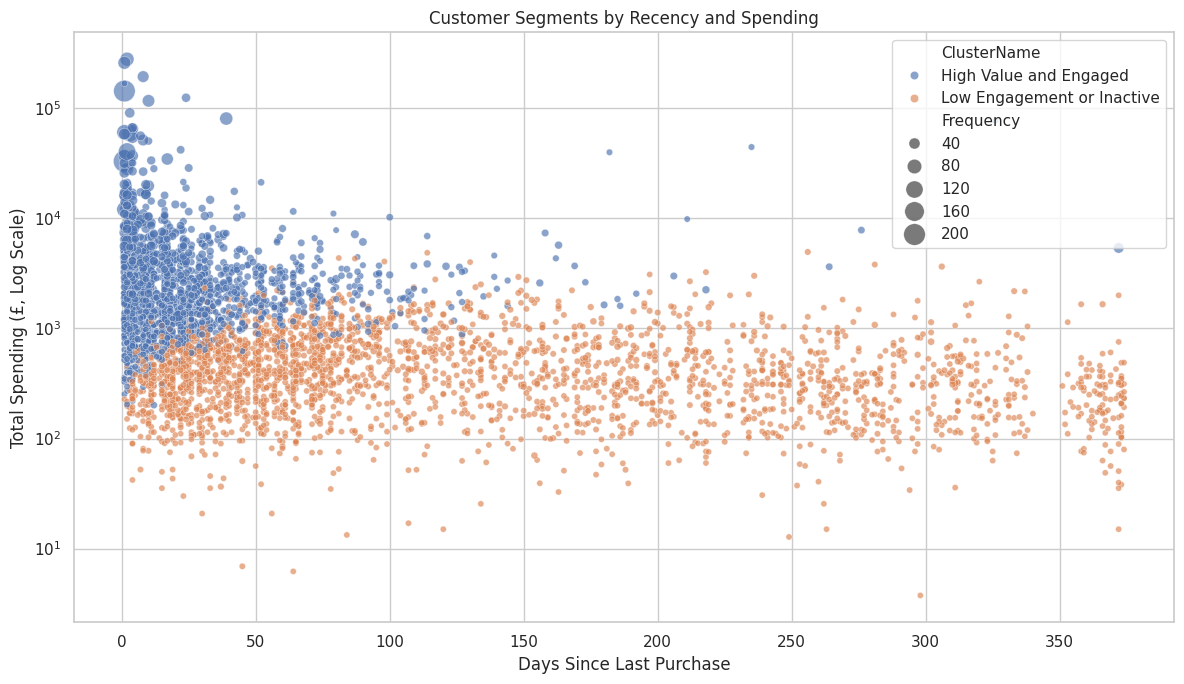

In [20]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="ClusterName",
    size="Frequency",
    sizes=(20, 250),
    alpha=0.65
)

plt.yscale("log")
plt.title("Customer Segments by Recency and Spending")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending (£, Log Scale)")
plt.tight_layout()
plt.show()

In [21]:
rfm.to_csv(
    "rfm_customer_segments.csv",
    index=False
)

5.10 Compare rules with machine learning

In [17]:
comparison = pd.crosstab(
    rfm["RFM_Segment"],
    rfm["Cluster"],
    margins=True
)

comparison

Cluster,0,1,All
RFM_Segment,,,
At Risk,423,232,655
Champions,0,477,477
Lost Customers,902,2,904
Loyal Customers,165,872,1037
Needs Attention,787,4,791
New Customers,69,3,72
Potential Loyalists,326,76,402
All,2672,1666,4338


5.11 Save the results

In [18]:
rfm.to_csv(
    "rfm_customer_segments.csv",
    index=False
)

segment_summary.to_csv(
    "rfm_segment_summary.csv",
    index=False
)

cluster_profile.to_csv(
    "kmeans_cluster_profile.csv",
    index=False
)

cluster_results.to_csv(
    "kmeans_model_selection.csv",
    index=False
)

print("Customer segmentation files saved.")

Customer segmentation files saved.


In [19]:
high_value_cluster = cluster_profile.loc[
    cluster_profile["AverageSpending"].idxmax(),
    "Cluster"
]

rfm["ClusterName"] = np.where(
    rfm["Cluster"] == high_value_cluster,
    "High Value and Engaged",
    "Low Engagement or Inactive"
)

rfm[[
    "CustomerID",
    "RFM_Segment",
    "Cluster",
    "ClusterName"
]].head()

,CustomerID,RFM_Segment,Cluster,ClusterName
0,12346,Lost Customers,1,High Value and Engaged
1,12347,Champions,1,High Value and Engaged
2,12348,At Risk,1,High Value and Engaged
3,12349,Needs Attention,0,Low Engagement or Inactive
4,12350,Lost Customers,0,Low Engagement or Inactive
